# Final Project Phase 3 Summary

# Video Presentation

[Open the project presentation video](media/2316FinalPresentation.mp4)



# Data Collection and Cleaning


Transfer/update the data collection and cleaning you created for Phase II below. You may include additional cleaning functions if you have extra datasets. If no changes are necessary, simply copy and paste your phase II parsing/cleaning functions.


## Downloaded Dataset Requirement



In [1]:
from pathlib import Path


def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "data" / "Subways.csv").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing data/Subways.csv")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"


In [2]:
import csv
import pandas as pd


def data_parser(file_path):
    source_path = Path(file_path)
    if not source_path.is_absolute():
        source_path = DATA_DIR / source_path
    with open(source_path, 'r') as f:
        reader = csv.reader(f, delimiter=',')
        data = list(reader)
    df = pd.DataFrame(data[1:], columns=data[0])

    df = df.rename(columns={'Lost Time Accidents': 'Accidents',
                            'Lost Time Accident Rate': 'LostTimeRate'})

    df = df[df['Department'] == 'Subways']
    df.reset_index(drop=True, inplace=True)
    df.to_csv(DATA_DIR / 'cleaned_DownloadedData.csv', index=False)

    return df

############ Function Call ############
data_parser('Subways.csv')

,Month,Department,Accidents,Employees,LostTimeRate
0,01/01/2021,Subways,104,28903,0.36
1,02/01/2021,Subways,114,28822,0.4
2,03/01/2021,Subways,104,28702,0.36
3,04/01/2021,Subways,93,28702,0.32
4,05/01/2021,Subways,103,28567,0.36
5,06/01/2021,Subways,107,28541,0.37
6,07/01/2021,Subways,111,28428,0.39
7,08/01/2021,Subways,94,28447,0.33
8,09/01/2021,Subways,92,28539,0.32
9,10/01/2021,Subways,100,28696,0.35


## Web Collection Requirement \#1


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import io


def web_parser1(website):
    response = requests.get(website)
    html_content = response.text
    soup = BeautifulSoup(html_content, 'html.parser')
    table = soup.find('table', class_='wikitable')
    df = pd.read_html(io.StringIO(str(table)))[0]

    df.drop('Neighborhoods', axis=1, inplace=True)
    df.rename(columns={'Community Board (CB)': 'Borough',
                       'Pop. Census 2010': 'Population'}, inplace=True)

    df['Borough'] = df['Borough'].str.split('CB').str[0].str.replace(r'\W', '', regex=True).str.strip()

    df = df.iloc[:-1]
    grouped_df = df.groupby('Borough').agg({'Area km2': 'sum', 'Population': 'sum', 'Pop./ km2': 'mean'}).reset_index()
    grouped_df = grouped_df.iloc[:-1]
    grouped_df['Pop./ km2'] = grouped_df['Pop./ km2'].round(2)
    grouped_df[['Area km2', 'Population']] = grouped_df[['Area km2', 'Population']].astype(int)
    grouped_df.to_csv(DATA_DIR / 'cleaned_HTMLData.csv', index=False)

    return grouped_df

############ Function Call ############
web_parser1('https://en.wikipedia.org/wiki/Neighborhoods_in_New_York_City')

/var/folders/6y/spt598r17_dgcfx4prrmwk4m0000gq/T/ipykernel_15885/4179813389.py:10: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(html_content, 'html.parser')


ValueError: No tables found

## Web Collection Requirement #2

In [ ]:
import requests
import pandas as pd


def web_parser2(website):
    response = requests.get(website)
    data = response.json()
    df = pd.DataFrame(data)
    df.drop(['on_street_name', 'off_street_name', 'contributing_factor_vehicle_1',
             'contributing_factor_vehicle_2', 'vehicle_type_code1', 'vehicle_type_code2',
             'zip_code', 'latitude', 'longitude', 'location', 'contributing_factor_vehicle_3',
             'vehicle_type_code_3', 'contributing_factor_vehicle_4',
             'contributing_factor_vehicle_5', 'vehicle_type_code_5', 'vehicle_type_code_4',
             'cross_street_name', 'crash_time'], axis=1, inplace=True)

    df = df.rename(columns={'crash_date': 'CrashDate',
                            'number_of_persons_injured': 'PersonsInjured',
                            'number_of_persons_killed': 'PersonsKilled',
                            'number_of_pedestrians_injured': 'PedestriansInjured',
                            'number_of_pedestrians_killed': 'PedestriansKilled',
                            'number_of_cyclist_injured': 'CyclistsInjured',
                            'number_of_cyclist_killed': 'CyclistsKilled',
                            'number_of_motorist_injured': 'MotoristsInjured',
                            'number_of_motorist_killed': 'MotoristsKilled',
                            'collision_id': 'CollisionID',
                            'borough': 'Borough'})

    df = df.dropna(subset=['Borough'])
    df = df.drop_duplicates(subset=['CollisionID'])
    df['CrashDate'] = pd.to_datetime(df['CrashDate'])
    df = df[df['CrashDate'].dt.year == 2023]
    df['Borough'] = df['Borough'].apply(lambda value: value.title())

    injury_columns = ['PersonsInjured', 'PedestriansInjured', 'CyclistsInjured', 'MotoristsInjured']
    fatality_columns = ['PersonsKilled', 'PedestriansKilled', 'CyclistsKilled', 'MotoristsKilled']
    df['PplInjured'] = df[injury_columns].astype(int).sum(axis=1)
    df['PpleKilled'] = df[fatality_columns].astype(int).sum(axis=1)
    df.drop(injury_columns + fatality_columns, axis=1, inplace=True)

    df.sort_values(by='CrashDate', inplace=True)
    df.reset_index(drop=True, inplace=True)
    df.to_csv(DATA_DIR / 'cleaned_APIData.csv', index=False)

    return df

############ Function Call ############
limit = 500000
web_parser2(f'https://data.cityofnewyork.us/resource/h9gi-nx95.json?$limit={limit}')

,CrashDate,CollisionID,Borough,PplInjured,PpleKilled
0,2023-01-01,4595229,Staten Island,0,0
1,2023-01-01,4599239,Queens,0,0
2,2023-01-01,4594477,Brooklyn,2,0
3,2023-01-01,4596354,Manhattan,0,0
4,2023-01-01,4594553,Queens,2,0
...,...,...,...,...,...
65706,2023-12-31,4691670,Brooklyn,0,0
65707,2023-12-31,4691563,Brooklyn,0,0
65708,2023-12-31,4693919,Queens,0,0
65709,2023-12-31,4694027,Staten Island,4,0


## Additional Dataset Parsing/Cleaning Functions

In [ ]:
import requests
import pandas as pd


def extra_source(jsonEnd):
    response = requests.get(jsonEnd)
    data = response.json()
    df = pd.DataFrame(data)

    df.drop(['subways_of_comparable_pre_pandemic_day', 'buses_of_comparable_pre_pandemic_day',
             'metro_north_of_comparable_pre_pandemic_day',
             'access_a_ride_total_scheduled_trips', 'access_a_ride_of_comparable_pre_pandemic_day',
             'bridges_and_tunnels_total_traffic',
             'bridges_and_tunnels_of_comparable_pre_pandemic_day',
             'staten_island_railway_total_estimated_ridership',
             'staten_island_railway_of_comparable_pre_pandemic_day',
             'lirr_of_comparable_pre_pandemic_day'], axis=1, inplace=True)

    df.rename(columns={'date': 'Date',
                       'subways_total_estimated_ridership': 'SubwayRiders',
                       'buses_total_estimated_ridersip': 'BusRiders',
                       'metro_north_total_estimated_ridership': 'MetroRiders',
                       'lirr_total_estimated_ridership': 'RailRoadRiders'}, inplace=True)

    df.dropna(inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df[df['Date'].dt.year == 2023]

    rider_columns = ['SubwayRiders', 'BusRiders', 'MetroRiders', 'RailRoadRiders']
    df[rider_columns] = df[rider_columns].astype(int)
    df.reset_index(drop=True, inplace=True)
    df.to_csv(DATA_DIR / 'cleaned_system_ridership.csv', index=False)

    return df

############ Function Call ############
extra_source(f'https://data.ny.gov/resource/vxuj-8kew.json?$limit={1517}')

,Date,SubwayRiders,BusRiders,MetroRiders,RailRoadRiders
0,2023-01-01,1675507,475226,66309,67722
1,2023-01-02,1938154,739507,72404,76247
2,2023-01-03,3175777,1268913,167136,179109
3,2023-01-04,3413052,1391449,170847,182834
4,2023-01-05,3428520,1378698,166642,175278
...,...,...,...,...,...
360,2023-12-27,2912007,955890,186541,220010
361,2023-12-28,3064841,969231,193235,218546
362,2023-12-29,3198885,1007697,210361,237781
363,2023-12-30,2440211,720564,121647,121688


#Inconsistency Revisions
 **If you were requested to revise your inconsistency section from Phase II, enter your responses here. Otherwise, ignore this section.**

For each inconsistency (NaN, null, duplicate values, empty strings, etc.) you discover in your datasets, write at least 2 sentences stating the significance, how you identified it, and how you handled it.

1. In the Additional Dataset, we converted the date that was given to us in string format into the Datetime module for better analysis and comparison between datasets. This will allow us to properly visualize the data and create our insights with dates rather than working with strings.

2. In the Web Collection #1 dataset, for the population / km^2 column, we rounded it to 2 decimal places, which is an appropriate amount of significant figures for a population density statistic.

3. In the Web Collection #2 dataset, we removed duplicate rows based on Collision ID. This is a valiid inconsistency because we don't want to double count a car accident when analyzing the numerical rates and volume of car accidents.

## Data Sources

Include sources (as links) to your datasets. If any of these are different from your sources used in Phase II, please <b>clearly</b> specify.

*   Downloaded Dataset Source: https://data.ny.gov/api/views/8vjt-4zv4/rows.csv?accessType=DOWNLOAD
*   Web Collection #1 Source: https://en.wikipedia.org/wiki/Neighborhoods_in_New_York_City
*   Web Collection #2 Source: https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/data_preview
*   Additional Dataset2: https://data.ny.gov/Transportation/MTA-Daily-Ridership-Data-Beginning-2020/vxuj-8kew/data_preview



# Data Analysis
For the Data Analysis section, you are required to utilize your data to complete the following:

*   Create at least 5 insights
*   Generate at least 3 data visualizations

Create a function for each of the following sections mentioned above. Do not forget to fill out the explanation section for each function.

Make sure your data analysis is not too simple. Performing complex aggregation and using modules not taught in class shows effort, which will increase the chance of receiving full credit.

# Topic Summary


In this project, we are utilizing multiple datasets to investigate the relationships between traffic accidents, subway lost time rates, and subway ridership data on public transportation utilization across New York City boroughs from 2022 to 2023. By analyzing traffic accident data, we aim to understand the impact of road safety incidents on commuters' mode of travel choice. Concurrently, examining subway lost time rates provides insights into the safety performance of the subway system and its potential influence on commuters' confidence in using public transportation. Additionally, evaluating subway ridership data enables me to assess the fluctuation in ridership patterns and uncover any correlations with traffic accidents and subway safety metrics.

## Insights

In [ ]:
#@title Insight 1
import requests
import pandas as pd

def insight1():
    limit = 100000
    fullLimit = 53410227
    choice = fullLimit
    crashes = web_parser2(f'https://data.cityofnewyork.us/resource/h9gi-nx95.json?$limit={choice}')

    borough_crash_counts = crashes.groupby('Borough').size().reset_index(name='CrashCount')
    borough_crash_counts.sort_values(by='CrashCount', ascending=False, inplace=True)
    borough_crash_counts.reset_index(drop=True, inplace=True)
    borough_crash_counts = borough_crash_counts.iloc[:-1]

    populationCount = web_parser1('https://en.wikipedia.org/wiki/Neighborhoods_in_New_York_City')

    merged_df = pd.merge(borough_crash_counts, populationCount, on='Borough', how='inner')

    merged_df['PeoplePerCrash'] = round(merged_df['Population'] / merged_df['CrashCount'], 2)
    merged_df.sort_values(by='PeoplePerCrash', ascending=True, inplace=True)
    merged_df.reset_index(drop=True, inplace=True)

        # Calculate the mean of numeric columns
    column_averages = merged_df.drop(columns=['Borough']).mean().to_frame().T
    column_averages['Borough'] = 'Average'

    # Concatenate the row containing column averages
    merged_df = pd.concat([merged_df, column_averages], ignore_index=True)

    return merged_df

############ Function Call ############
insight1()

,Borough,CrashCount,Area km2,Population,Pop./ km2,PeoplePerCrash
0,Brooklyn,22887.00,174.00,2465299.00,15847.390,107.720
1,Queens,17783.00,254.00,2240510.00,11220.570,125.990
2,Manhattan,11817.00,57.00,1529357.00,26506.920,129.420
3,Bronx,10500.00,96.00,1380697.00,17564.500,131.490
4,Average,15746.75,145.25,1903965.75,17784.845,123.655


The metric "People Per Crash" represents the average number of people residing in a borough per reported crash incident. A higher value in this metric indicates fewer crash incidents relative to the population size, suggesting potentially safer conditions in terms of vehicular accidents. Conversely, a lower value suggests a higher frequency of crashes per capita, potentially indicating higher risk or congestion issues. In this analysis, the Bronx exhibits the highest "People Per Crash" ratio, implying relatively fewer crash incidents per resident compared to Brooklyn.

In [ ]:
#@title Insight 2
import pandas as pd
from datetime import datetime

def insight2():
    # Load the public transportation ridership data
    pt_ridership = extra_source(f'https://data.ny.gov/resource/vxuj-8kew.json?$limit={1517}')

    # Convert the 'Date' column to datetime format
    pt_ridership['Date'] = pd.to_datetime(pt_ridership['Date'])

    # Extract the month and year from the 'Date' column and create a new column with formatted strings
    pt_ridership['Month'] = pt_ridership['Date'].dt.strftime('%b %Y')

    # Group the data by month and sum the ridership values
    monthly_ridership = pt_ridership.groupby('Month').agg({'SubwayRiders': 'sum',
                                                           'BusRiders': 'sum',
                                                           'MetroRiders': 'sum',
                                                           'RailRoadRiders': 'sum'})

    # Reset the index to make 'Month' the first column and use the default numeric index
    monthly_ridership.reset_index(inplace=True)

    # Convert the 'Month' column to datetime objects for sorting
    monthly_ridership['Month'] = pd.to_datetime(monthly_ridership['Month'], format='%b %Y')

    # Sort the DataFrame by the 'Month' column
    monthly_ridership.sort_values(by='Month', inplace=True)
    monthly_ridership['Month'] = monthly_ridership['Month'].dt.strftime('%b %Y')

    # Reset the index to ensure it follows the sorted order
    monthly_ridership.reset_index(drop=True, inplace=True)

    lostSubwayTime = data_parser('Subways.csv')
    lostSubwayTime['Month'] = pd.to_datetime(lostSubwayTime['Month'], format='%m/%d/%Y')
    lostSubwayTime = lostSubwayTime[lostSubwayTime['Month'].dt.year == 2023]
    lostSubwayTime['Month'] = lostSubwayTime['Month'].dt.strftime('%b %Y')


    merged_df = pd.merge(monthly_ridership, lostSubwayTime, on='Month', how='inner')

    merged_df.drop(['BusRiders', 'MetroRiders', 'RailRoadRiders', 'Department','Employees', 'LostTimeRate'], axis = 1, inplace = True)

    merged_df['SubwayRiders'] = merged_df['SubwayRiders'].astype(int)
    merged_df['Accidents'] = merged_df['Accidents'].astype(int)

    merged_df['RidersPerAccident'] = round(merged_df['SubwayRiders'] / merged_df['Accidents'], 2)

    merged_df.sort_values(by='RidersPerAccident', ascending = False, inplace = True)
    merged_df.reset_index(drop=True, inplace=True)


    return merged_df

############ Function Call ############
insight2()

,Month,SubwayRiders,Accidents,RidersPerAccident
0,Dec 2023,96887660,60,1614794.33
1,Oct 2023,104296170,89,1171867.08
2,Sep 2023,95330225,95,1003476.05
3,Apr 2023,94198922,99,951504.26
4,Jun 2023,97457013,103,946184.59
5,Jul 2023,90797995,97,936061.80
6,May 2023,104435152,114,916097.82
7,Aug 2023,93997299,104,903820.18
8,Nov 2023,98487231,111,887272.35
9,Mar 2023,101030692,120,841922.43


### Insight 2 Explanation
The "Riders Per Incident" column in the provided dataset reflects the average number of subway riders between maintenance or delay incidents. A higher value indicates smoother operations and fewer disruptions, suggesting a more efficient and reliable transit system. Conversely, a lower average suggests potential issues with service reliability or operational challenges that may warrant attention from transit authorities. This insight allows for a nuanced understanding of subway system performance and highlights areas where improvements in service reliability may be beneficial.

In [ ]:
import pandas as pd
def insight3():
  limit = 1000000
  fullLimit = 53410227
  choice = fullLimit
  crashes = web_parser2(f'https://data.cityofnewyork.us/resource/h9gi-nx95.json?$limit={choice}')

  # Reformatting of the month column to allow for sorting and grouping
  crashes['CrashDate'] = pd.to_datetime(crashes['CrashDate'])
  crashes['Month'] = crashes['CrashDate'].dt.strftime('%b')
  crashes_by_month = crashes.groupby('Month').size().reset_index(name='CrashCount')
  crashes_by_month['Month'] = pd.to_datetime(crashes_by_month['Month'], format='%b')
  crashes_by_month.sort_values(by='Month', inplace=True)
  crashes_by_month['Month'] = crashes_by_month['Month'].dt.strftime('%b')

  # Calling public transportation ridership data from Additional Dataset
  pt_ridership = extra_source(f'https://data.ny.gov/resource/vxuj-8kew.json?$limit={1517}')
  pt_ridership.drop(['BusRiders'], axis=1, inplace=True)

  # Date formatting
  pt_ridership['Date'] = pd.to_datetime(pt_ridership['Date'])

  # Extract the month and year from the 'Date' column and create a new column with formatted strings
  pt_ridership['Month'] = pt_ridership['Date'].dt.strftime('%b')
  monthly_ridership = pt_ridership.groupby('Month').agg({'SubwayRiders': 'sum',
                                                         'MetroRiders': 'sum',
                                                         'RailRoadRiders': 'sum'})

  # Reset the index to make 'Month' the first column and use the default numeric index
  monthly_ridership.reset_index(inplace=True)

  merged_df = pd.merge(crashes_by_month, monthly_ridership, on='Month', how='inner')

  # Add a 'TotalPublicTransport' column summing subway, metro, and railroad ridership
  merged_df['TotalPublicTransport'] = merged_df[['SubwayRiders', 'MetroRiders', 'RailRoadRiders']].sum(axis=1)

  return merged_df

### Function Call ###
insight3()

,Month,CrashCount,SubwayRiders,MetroRiders,RailRoadRiders,TotalPublicTransport
0,Jan,4959,88999287,4156954,4529728,97685969
1,Feb,4520,84299462,3810260,4256489,92366211
2,Mar,5513,101030692,4674166,5201989,110906847
3,Apr,5195,94198922,4471810,4917537,103588269
4,May,6095,104435152,5182089,5616409,115233650
5,Jun,5611,97457013,5142382,5806179,108405574
6,Jul,5668,90797995,4721239,5418885,100938119
7,Aug,5511,93997299,4992583,5841314,104831196
8,Sep,5710,95330225,4914094,5606594,105850913
9,Oct,5996,104296170,5446892,6014657,115757719


### Insight 3 Explanation

This table provides a month-by-month analysis on the number of car accidents and the number of public transportation users. This allows us to see if people in NYC were using the subway, metro, or railroad more or less often in months where there were more car accidents in the street. This allows us to visualize a correlation between the values as will be see in Data Visualization 1.

In [ ]:
#@title Insight 4
def insight4():
  limit = 100000
  fullLimit = 53410227
  choice = fullLimit
  crashes = web_parser2(f'https://data.cityofnewyork.us/resource/h9gi-nx95.json?$limit={choice}')

  # Group by Borough and sum the number of people injured and killed
  borough_stats = crashes.groupby('Borough').agg({'PplInjured': 'sum'}).reset_index()

  # Sort in descending order of number of people injured.
  borough_stats.sort_values(by='PplInjured', ascending = False, inplace = True)

  # Removal of Staten Island because they are not connected to the NYC Subway or Public Transportation
  borough_stats = borough_stats.iloc[:-1]
  borough_stats.reset_index(drop=True, inplace=True)

  return borough_stats

############ Function Call ############
insight4()

,Borough,PplInjured
0,Brooklyn,23935
1,Queens,18598
2,Bronx,11357
3,Manhattan,10932


### Insight 4 Explanation

This insight provides us with an overview on the number of injured people in NYC due to car accidents. This is important information because it shows us the safer boroughs to drive through, which is helpful to our discussion in that the boroughs that have less accidents will probably not change to public transportation as often as the boroughs with a higher injury per accident value.

In [ ]:
import pandas as pd

def insight5():
  # Assuming you already have a DataFrame named lostSubwayTime
  lostSubwayTime = data_parser('Subways.csv')

  # Convert 'Month' column to datetime type
  lostSubwayTime['Month'] = pd.to_datetime(lostSubwayTime['Month'])

  # Filter the DataFrame for the year 2023
  lostSubwayTime = lostSubwayTime[lostSubwayTime['Month'].dt.year == 2023]

  # Convert 'Employees' column to integer type
  lostSubwayTime['Employees'] = lostSubwayTime['Employees'].astype(int)

  # Calculate the average number of employees affected
  avg_employees_affected = round(lostSubwayTime['Employees'].mean(), 2)

  # Call of total Crash Data
  limit = 100000
  fullLimit = 53410227
  choice = fullLimit
  crashes = web_parser2(f'https://data.cityofnewyork.us/resource/h9gi-nx95.json?$limit={choice}')

  # Calculating Average of people injured per accident
  avg_people_injured = round(crashes['PplInjured'].mean(), 2)

  # Create DataFrame
  average_df = pd.DataFrame({
      'Average Employeed Affected': [avg_employees_affected],
      'Average People Injured': [avg_people_injured],
  })

  return average_df

# Function call
insight5()


,Average Employeed Affected,Average People Injured
0,30150.5,1.03


### Insight 5 Explanation

This insight pulls two facts from two separate data sources for usage on the One-Pager. The statistics used provide an understanding of the frequency of car accidents and the frequency of subway failures. These two stats show us the rate in which the transportation services we use can experience failures or delays.

## Data Visualizations

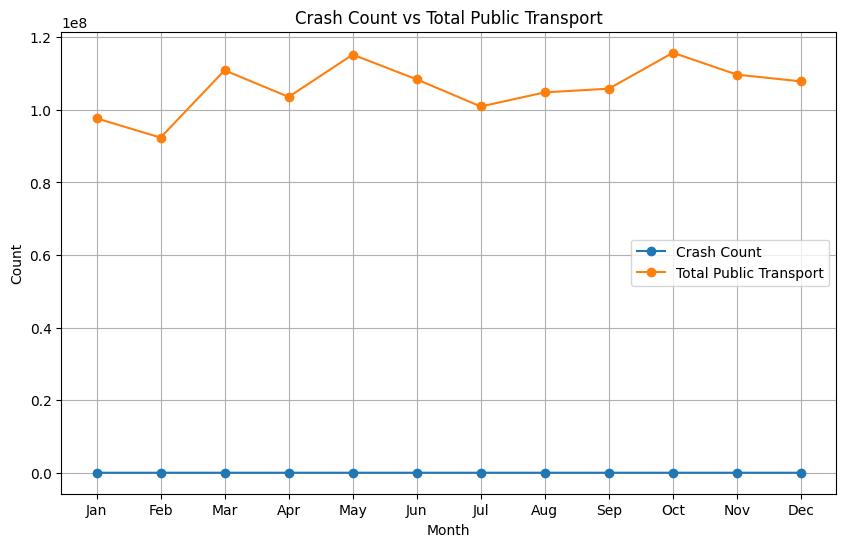

In [ ]:
#@title Visualization 1
import pandas as pd
import matplotlib.pyplot as plt


def visual1():
  crash_rider_df = insight3()
  plt.figure(figsize=(10, 6))

  # Plotting CrashCount
  plt.plot(crash_rider_df['Month'], crash_rider_df['CrashCount'], marker='o', label='Crash Count')

  # Plotting TotalPublicTransport
  plt.plot(crash_rider_df['Month'], crash_rider_df['TotalPublicTransport'], marker='o', label='Total Public Transport')

  # Adding labels and title
  plt.xlabel('Month')
  plt.ylabel('Count')
  plt.title('Crash Count vs Total Public Transport')
  plt.legend()

  # Displaying the plot
  plt.grid(True)
  plt.show()


############ Function Call ############
visual1()

### Visualization 1 Explanation

This is a line chart showing the correlation between the crash count and the total public transportation. The values seem off because there are so many more total public transportation riders than car accidents

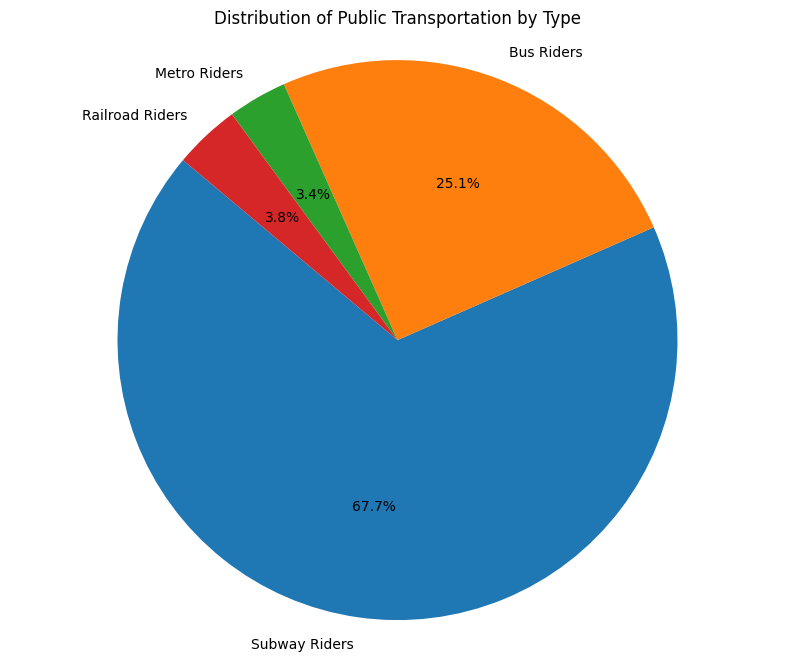

In [ ]:
#@title Visualization 2
import matplotlib.pyplot as plt

def visual2():
    riderDF = extra_source(f'https://data.ny.gov/resource/vxuj-8kew.json?$limit={1517}')

    # Calculate the total ridership for each type
    total_subway_riders = riderDF['SubwayRiders'].sum()
    total_bus_riders = riderDF['BusRiders'].sum()
    total_metro_riders = riderDF['MetroRiders'].sum()
    total_railroad_riders = riderDF['RailRoadRiders'].sum()

    # Create labels and sizes for the pie chart
    labels = ['Subway Riders', 'Bus Riders', 'Metro Riders', 'Railroad Riders']
    sizes = [total_subway_riders, total_bus_riders, total_metro_riders, total_railroad_riders]

    # Plotting the pie chart
    plt.figure(figsize=(10, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title('Distribution of Public Transportation by Type')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

    # Show the pie chart
    plt.show()

# Function call
visual2()

### Visualization 2 Explanation

This visualization displays the proportion of riders throughout 2023 based on the type of public transportation. There is a clear majority use of subways compared to the other 3 modes of transportation. This shows us the dependency the New York population has on the subway system, only emphasizng the importance of a lack of Lost Time Accidents and delays due to problems in the infrastructure and to maitenence.

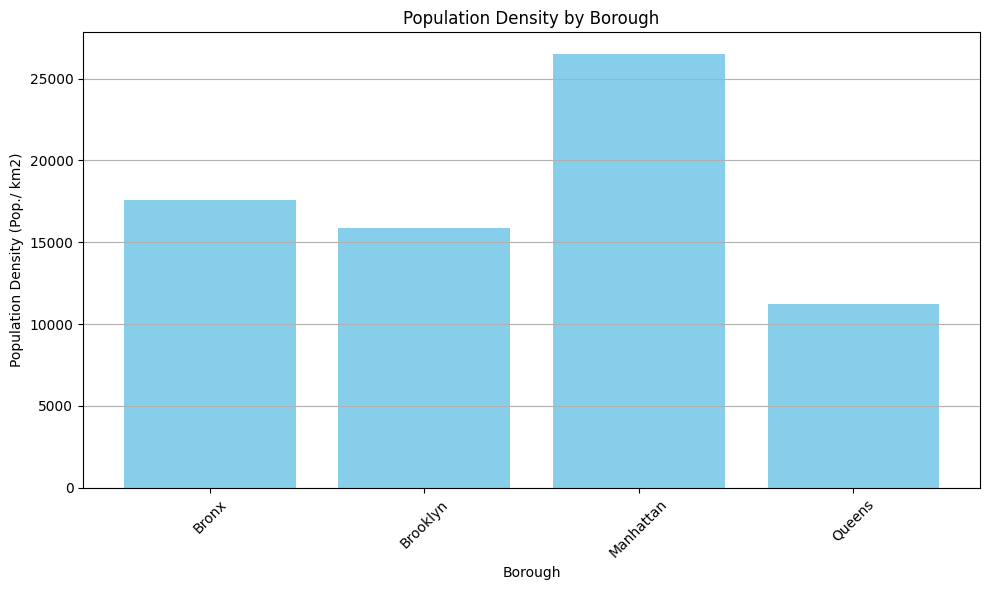

In [ ]:

import matplotlib.pyplot as plt
def visual3():
  population_df = web_parser1('https://en.wikipedia.org/wiki/Neighborhoods_in_New_York_City')

  # Plotting
  plt.figure(figsize=(10, 6))

  # Creating bars
  plt.bar(population_df['Borough'], population_df['Pop./ km2'], color='skyblue')

  # Adding labels and title
  plt.xlabel('Borough')
  plt.ylabel('Population Density (Pop./ km2)')
  plt.title('Population Density by Borough')

  # Rotating x-axis labels for better readability
  plt.xticks(rotation=45)

  # Displaying the plot
  plt.grid(axis='y')
  plt.tight_layout()
  plt.show()

############ Function Call ############
visual3()

### Visualization 3 Explanation

This visualization offers us the view of population density per borough, which is helpful when we are considering the different crash rates per borough and how they coincide with the populations in each borough. Manhattan, while having the highest population density, does not have the highest People Per Crash ratio, as seen in Insight 1

# Cited Sources

If you used any additional sources to complete your Data Analysis section, list them here:


*   Example Module Documentation
*   Example Stack Overflow Assistance



# Graphical User Interface (GUI) Implementation
If you decide to create a GUI for Phase II, please create a separate Python file (.py) to build your GUI. You must submit both the completed PhaseII.ipynb and your Python GUI file.

# Submission

Prior to submitting your notebook to Gradescope, be sure to <b>run all functions within this file</b>. We will not run your functions ourselves, so we must see your outputs within this file in order to receive full credit.


# Standalone Script Code

This section incorporates functionality from the standalone Python scripts. Network-backed helpers are defined here but are not called automatically.

In [ ]:
import requests
import pandas as pd


def inspect_tlc_trip_sample(endpoint='https://data.cityofnewyork.us/resource/qp3b-zxtp.json'):
    response = requests.get(endpoint, timeout=30)
    response.raise_for_status()
    trips = response.json()
    return pd.DataFrame([
        {
            'passenger_count': trip.get('passenger_count'),
            'trip_distance': trip.get('trip_distance'),
        }
        for trip in trips[:2]
    ])

In [ ]:
def web_parser2_2022(website='https://data.cityofnewyork.us/resource/h9gi-nx95.json?$limit=5000'):
    response = requests.get(website, timeout=30)
    response.raise_for_status()
    records = [entry for entry in response.json()
               if entry.get('crash_date', '').startswith('2022')]
    records.sort(key=lambda entry: entry['crash_date'])

    columns_to_remove = [
        'zip_code', 'latitude', 'longitude', 'location', 'cross_street_name',
        'on_street_name', 'off_street_name', 'number_of_pedestrians_injured',
        'number_of_pedestrians_killed', 'number_of_cyclist_injured',
        'number_of_cyclist_killed', 'number_of_motorist_injured',
        'number_of_motorist_killed', 'contributing_factor_vehicle_3', 'index',
        'contributing_factor_vehicle_4', 'vehicle_type_code_3',
        'vehicle_type_code_4', 'contributing_factor_vehicle_5',
        'vehicle_type_code_5',
    ]
    for entry in records:
        entry['crash_date'] = entry['crash_date'].split('T')[0]
        for column in columns_to_remove:
            entry.pop(column, None)

    df = pd.DataFrame(records).dropna(subset=['borough'])
    for column in ('contributing_factor_vehicle_1', 'contributing_factor_vehicle_2'):
        if column in df.columns:
            df[column] = df[column].fillna('Unspecified')

    df = df.rename(columns={
        'borough': 'Borough',
        'crash_date': 'Crash Date',
        'crash_time': 'Crash Time',
        'number_of_persons_injured': 'Persons Injured',
        'number_of_persons_killed': 'Persons Killed',
        'contributing_factor_vehicle_1': 'Factor Vehicle 1',
        'contributing_factor_vehicle_2': 'Factor Vehicle 2',
        'collision_id': 'Collision ID',
        'vehicle_type_code1': 'Vehicle 1 Type',
        'vehicle_type_code2': 'Vehicle 2 Type',
    })
    df = df.drop_duplicates(subset=['Collision ID'])
    df['Borough'] = df['Borough'].str.title()
    df.reset_index(drop=True, inplace=True)
    df.to_csv(DATA_DIR / 'cleaned_APIData_2022.csv', index=False)
    return df

In [ ]:
def extra_source1(json_endpoint='https://data.ny.gov/resource/wujg-7c2s.json?$limit=100000'):
    response = requests.get(json_endpoint, timeout=30)
    response.raise_for_status()
    df = pd.DataFrame(response.json())

    columns_to_remove = [
        'georeference', 'transfers', 'fare_class_category', 'payment_method',
        'latitude', 'longitude', ':@computed_region_kjdx_g34t',
        ':@computed_region_yamh_8v7k', ':@computed_region_wbg7_3whc',
    ]
    df.drop(columns=columns_to_remove, errors='ignore', inplace=True)
    df.rename(columns={
        'borough': 'Borough',
        'transit_mode': 'Transit Mode',
        'ridership': 'Ridership',
        'station_complex': 'Station',
        'transit_timestamp': 'Timestamp',
        'station_complex_id': 'Station ID',
    }, inplace=True)
    df = df[df['Transit Mode'] == 'subway'].copy()
    df['Ridership'] = pd.to_numeric(df['Ridership'], errors='coerce')
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df.sort_values(by='Timestamp', inplace=True)
    df.reset_index(drop=True, inplace=True)
    df.to_csv(DATA_DIR / 'cleaned_station_ridership.csv', index=False)
    return df